<a href="https://colab.research.google.com/github/Faizan08khan/student-productivity-predictor/blob/main/Student_productivity_MLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [38]:
df=pd.read_csv("Student_Productivity_Dataset.csv")

In [39]:
df

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.0,Female,4.2,5.5,5.2,1.6,95.5,100.0,6.6,5.0,7.7,8.5,Average,No,9.0,6.3,6.51,80.59,High
9996,9997,24.0,Male,7.1,6.7,4.0,3.2,64.3,74.5,4.0,0.5,6.8,9.4,Good,Yes,7.0,7.1,6.97,62.95,Medium
9997,9998,24.0,Male,6.4,4.4,6.7,3.3,74.1,100.0,10.0,4.5,5.4,1.0,Average,No,0.0,8.2,1.80,43.79,Low
9998,9999,19.0,Male,8.1,6.8,3.5,4.1,59.5,85.9,7.2,4.6,5.0,5.8,Poor,Yes,4.1,3.5,5.24,49.48,Medium


In [40]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

In [42]:
df.shape

(10000, 20)

In [43]:
df.drop_duplicates(inplace=True)

In [44]:
df.shape

(10000, 20)

In [45]:
df.isnull().sum()

,0
Student_ID,0
Age,155
Gender,119
Study_Hours_Per_Day,165
Sleep_Hours_Per_Night,106
Screen_Time_Hours,132
Social_Media_Hours,80
Attendance_Percentage,122
Assignments_Completed,118
Class_Participation_Score,185


In [46]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

In [47]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,119
Study_Hours_Per_Day,165
Sleep_Hours_Per_Night,106
Screen_Time_Hours,132
Social_Media_Hours,80
Attendance_Percentage,122
Assignments_Completed,118
Class_Participation_Score,185


In [48]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

In [49]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Study_Hours_Per_Day,165
Sleep_Hours_Per_Night,106
Screen_Time_Hours,132
Social_Media_Hours,80
Attendance_Percentage,122
Assignments_Completed,118
Class_Participation_Score,185


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               10000 non-null  float64
 2   Gender                            10000 non-null  object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

In [51]:
df["Internet_Quality"].fillna(df["Internet_Quality"].mode()[0], inplace=True)
df["Part_Time_Job"].fillna(df["Part_Time_Job"].mode()[0], inplace=True)
df["Performance_Category"].fillna(df["Performance_Category"].mode()[0], inplace=True)

In [52]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Study_Hours_Per_Day,165
Sleep_Hours_Per_Night,106
Screen_Time_Hours,132
Social_Media_Hours,80
Attendance_Percentage,122
Assignments_Completed,118
Class_Participation_Score,185


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               10000 non-null  float64
 2   Gender                            10000 non-null  object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

In [54]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               10000 non-null  float64
 2   Gender                            10000 non-null  object 
 3   Study_Hours_Per_Day               10000 non-null  float64
 4   Sleep_Hours_Per_Night             10000 non-null  float64
 5   Screen_Time_Hours                 10000 non-null  float64
 6   Social_Media_Hours                10000 non-null  float64
 7   Attendance_Percentage             10000 non-null  float64
 8   Assignments_Completed             10000 non-null  float64
 9   Class_Participation_Score         10000 non-null  float64
 10  Physical_Activity_Hours_Per_Week  10000 non-null  float64
 11  Stress_Level                      10000 non-null  float64
 12  Motiv

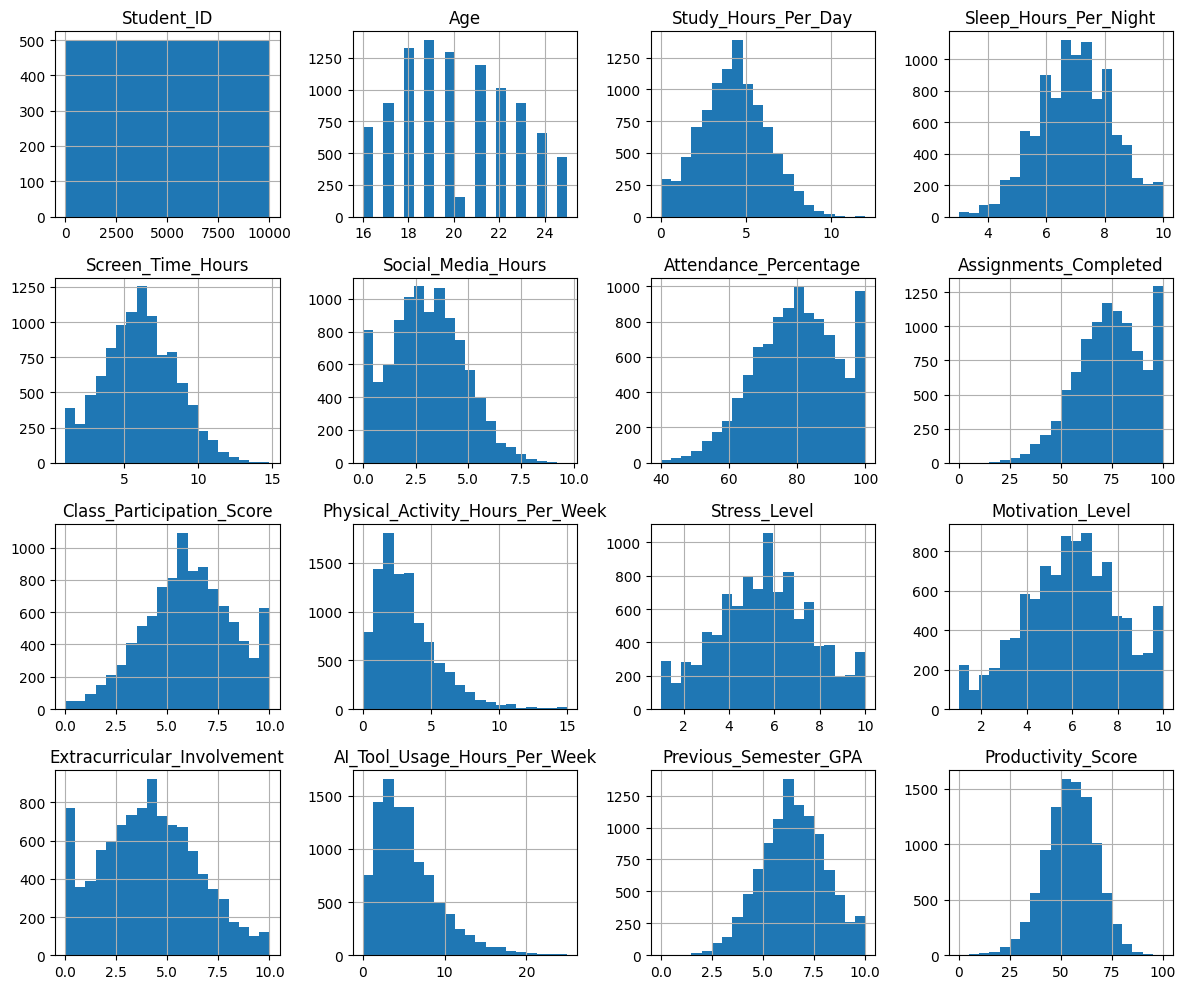

In [56]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='Gender'>

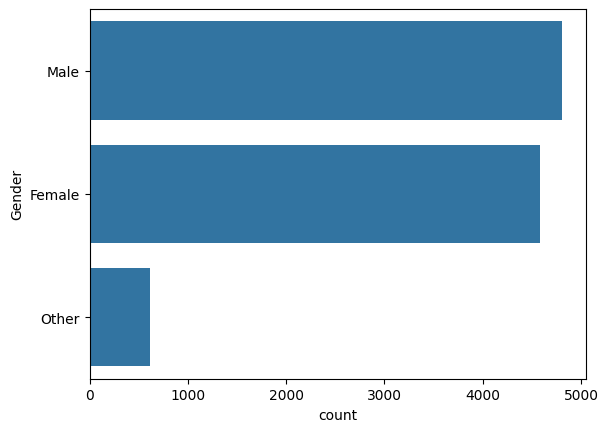

In [57]:
sns.countplot(df["Gender"])

<Axes: xlabel='count', ylabel='Performance_Category'>

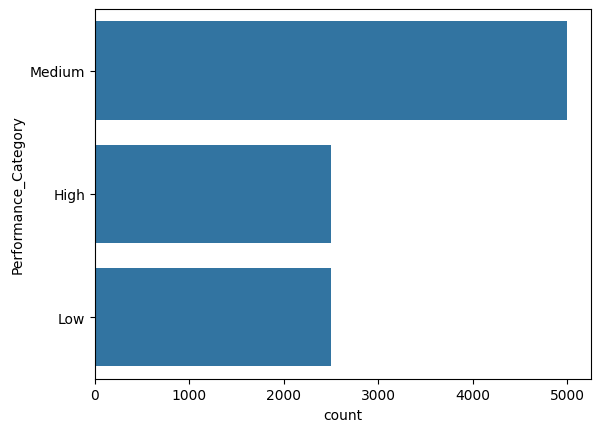

In [58]:
sns.countplot(df["Performance_Category"])

<Axes: xlabel='count', ylabel='Internet_Quality'>

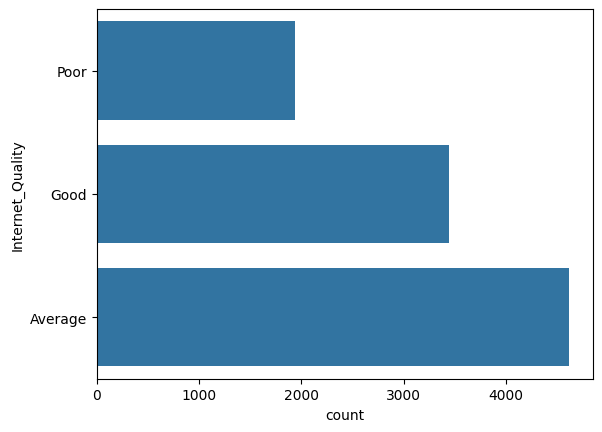

In [59]:
sns.countplot(df["Internet_Quality"])

<Axes: xlabel='count', ylabel='Part_Time_Job'>

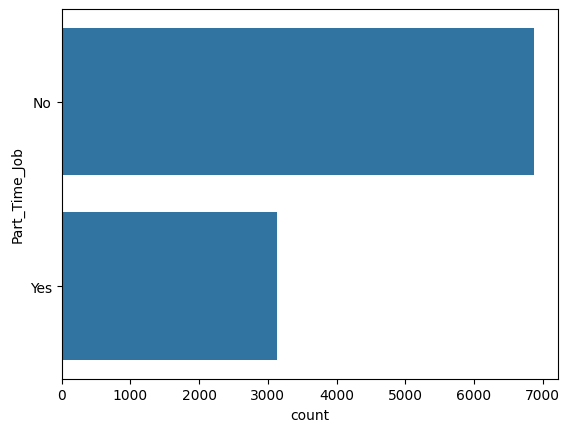

In [60]:
sns.countplot(df["Part_Time_Job"])

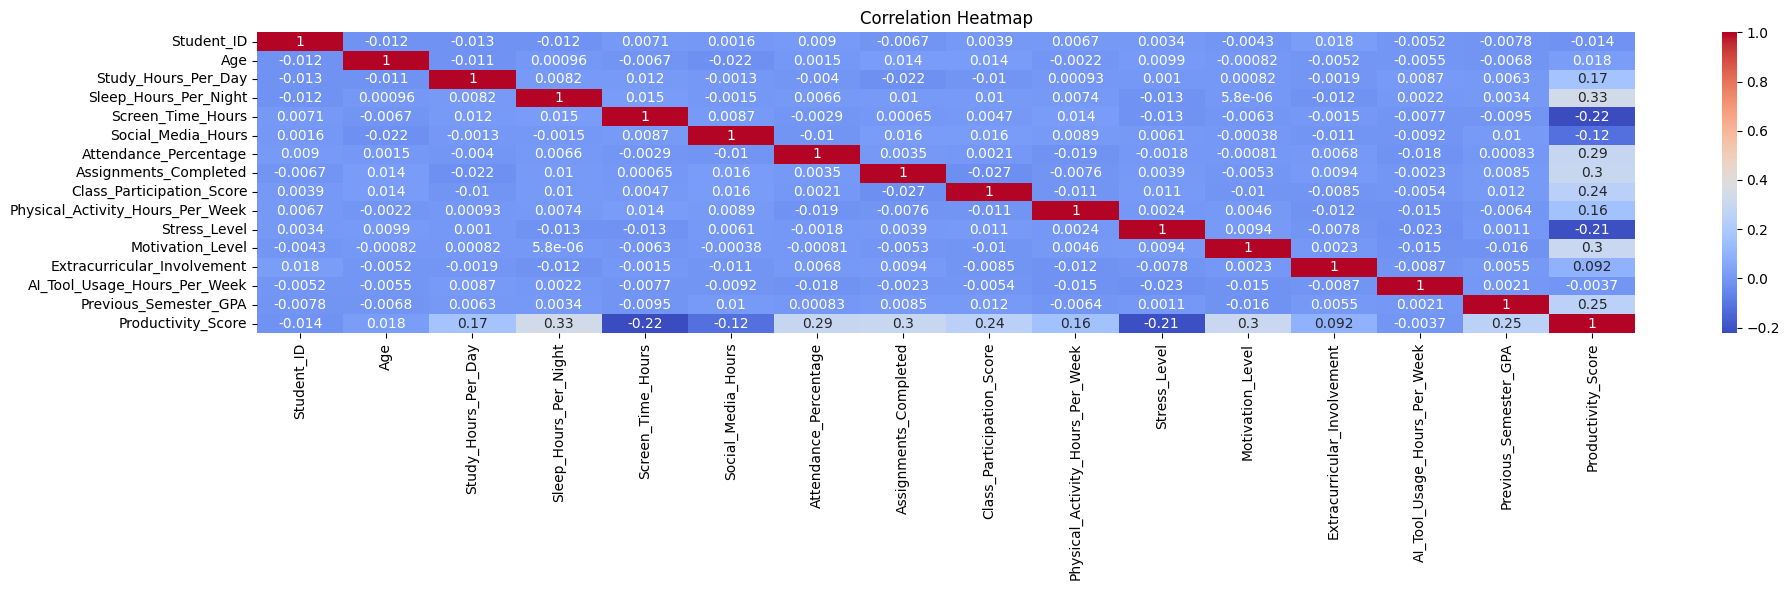

In [61]:
plt.figure(figsize=(20, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [62]:
df=pd.get_dummies(df,columns=['Gender','Internet_Quality','Part_Time_Job','Performance_Category'],drop_first=True)

In [63]:
df= df.astype(int)

In [64]:
df.describe()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,...,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Gender_Male,Gender_Other,Internet_Quality_Good,Internet_Quality_Poor,Part_Time_Job_Yes,Performance_Category_Low,Performance_Category_Medium
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,20.13280,3.782800,6.528300,5.616200,2.607600,79.391900,73.836000,5.54430,2.749600,...,5.09140,5.997600,54.112000,0.480500,0.061100,0.344000,0.194300,0.312900,0.250000,0.500000
std,2886.89568,2.47814,1.939072,1.338947,2.401223,1.704908,12.320734,16.547963,2.17295,2.260489,...,3.87628,1.605071,12.344776,0.499645,0.239526,0.475065,0.395681,0.463697,0.433034,0.500025
min,1.00000,16.00000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.00000,2.000000,6.000000,4.000000,1.000000,71.000000,63.000000,4.00000,1.000000,...,2.00000,5.000000,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5000.50000,20.00000,4.000000,7.000000,6.000000,3.000000,80.000000,74.000000,6.00000,2.000000,...,4.00000,6.000000,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,7500.25000,22.00000,5.000000,7.000000,7.000000,4.000000,89.000000,86.000000,7.00000,4.000000,...,7.00000,7.000000,63.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.250000,1.000000
max,10000.00000,25.00000,12.000000,10.000000,14.000000,9.000000,100.000000,100.000000,10.00000,15.000000,...,25.00000,10.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [65]:
df.head()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,...,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Gender_Male,Gender_Other,Internet_Quality_Good,Internet_Quality_Poor,Part_Time_Job_Yes,Performance_Category_Low,Performance_Category_Medium
0,1,19,2,5,7,2,86,75,3,2,...,16,5,51,1,0,0,1,0,0,1
1,2,25,5,6,6,4,93,99,7,0,...,2,6,74,1,0,1,0,0,0,0
2,3,22,6,5,7,4,66,75,4,1,...,3,7,34,1,0,0,0,0,1,0
3,4,21,1,8,6,2,62,51,3,2,...,8,6,53,0,0,0,1,0,0,1
4,5,17,7,6,4,3,87,37,8,3,...,5,5,57,1,0,0,0,0,0,1


In [66]:
from sklearn.model_selection import train_test_split
X=df.drop('Productivity_Score',axis=1)
y=df['Productivity_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor

# create model
rf_model= RandomForestRegressor(n_estimators=100, random_state=42)

# fit model
rf_model.fit(X_train, y_train)

# predict
y_pred = rf_model.predict(X_test)


In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Example usage
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)


Mean Squared Error: 22.395055050000003
Mean Absolute Error: 3.847725
R² Score: 0.8437352855449961


In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import numpy as np
rf = RandomForestRegressor(n_estimators=50, random_state=42)
r2_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("R² scores:", r2_scores)
print("Mean R²:", np.mean(r2_scores))
mse_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
print("MSE scores:", -mse_scores)
print("Mean MSE:", -np.mean(mse_scores))


R² scores: [0.84483694 0.8438183  0.84966442 0.84754142 0.83182503]
Mean R²: 0.843537223867845
MSE scores: [23.4528804 23.0453242 23.0557536 24.9423608 24.5037326]
Mean MSE: 23.800010320000002


In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
models = {"Linear Regression": LinearRegression(),
          "Gradient Boosting": GradientBoostingRegressor(),
          "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "R²:", r2_score(y_test, preds))


Linear Regression R²: 0.8523853790022654
SVR R²: 0.0016128997868779527
Gradient Boosting R²: 0.8497735362710751
Random Forest R²: 0.8437352855449961
